# Corrosion Rate Prediction: Fuel System Materials

**Goal:** Predict `corrosion_rate_mm_per_y` from environmental, chemical, and material
process parameters, compare multiple models.


In [50]:
# Core
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Machine learning models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor, RandomForestRegressor

# XGBoost
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost is not installed in this environment. Install with: pip install xgboost")

# Evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)


## 1. Load & Inspect the Data

In [51]:
df = pd.read_csv("corrosion_fuel.csv")
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,material,ethanol_pct,temperature_C,water_ppm,chloride_mg_L,dissolved_O2_ppm,TAN_mgKOH_g,conductivity_uS_cm,flow_velocity_m_s,exposure_hours,surface_roughness_Ra_um,inhibitor_present,pH,corrosion_rate_mm_per_y
0,Brass,15,55.09,255.6,0.67,7.09,0.177,77.70,1.049,87,1.314,0,6.09,0.01158
1,Al6061,0,58.24,369.7,4.75,7.46,0.005,27.35,0.215,274,0.771,0,6.59,0.00741
2,SS304,15,55.46,299.1,3.76,3.49,0.172,65.03,0.517,198,1.631,1,6.80,0.00109
3,LowCarbonSteel,5,33.69,514.9,6.12,0.78,0.095,50.44,1.054,60,1.135,1,6.73,0.03858
4,Brass,0,47.33,88.6,17.49,3.44,0.168,28.42,0.173,243,0.751,0,6.75,0.01547


In [52]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   material                 10000 non-null  object 
 1   ethanol_pct              10000 non-null  int64  
 2   temperature_C            10000 non-null  float64
 3   water_ppm                10000 non-null  float64
 4   chloride_mg_L            10000 non-null  float64
 5   dissolved_O2_ppm         10000 non-null  float64
 6   TAN_mgKOH_g              10000 non-null  float64
 7   conductivity_uS_cm       10000 non-null  float64
 8   flow_velocity_m_s        10000 non-null  float64
 9   exposure_hours           10000 non-null  int64  
 10  surface_roughness_Ra_um  10000 non-null  float64
 11  inhibitor_present        10000 non-null  int64  
 12  pH                       10000 non-null  float64
 13  corrosion_rate_mm_per_y  10000 non-null  float64
dtypes: float64(10), int64(3

In [53]:
df.describe()


,ethanol_pct,temperature_C,water_ppm,chloride_mg_L,dissolved_O2_ppm,TAN_mgKOH_g,conductivity_uS_cm,flow_velocity_m_s,exposure_hours,surface_roughness_Ra_um,inhibitor_present,pH,corrosion_rate_mm_per_y
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000
mean,10.000000,42.600636,350.033300,9.053665,4.282796,0.131016,49.905819,0.539619,179.800200,1.198807,0.2953,6.597920,0.018796
std,7.071421,15.797555,138.211663,7.434563,2.167058,0.044751,23.529380,0.345322,90.398642,0.592182,0.4562,0.424716,0.017276
min,0.000000,15.000000,0.000000,0.020000,0.500000,0.005000,0.500000,0.000000,24.000000,0.050000,0.0000,5.500000,0.000430
25%,5.000000,28.977500,257.275000,3.640000,2.400000,0.100000,31.017500,0.264000,101.000000,0.785000,0.0000,6.310000,0.006777
50%,10.000000,42.810000,348.650000,7.120000,4.310000,0.131000,49.915000,0.496000,179.000000,1.188000,0.0000,6.590000,0.014330
75%,15.000000,56.060000,444.225000,12.370000,6.160000,0.161000,68.740000,0.767000,258.000000,1.596000,1.0000,6.890000,0.024950
max,20.000000,70.000000,876.800000,66.860000,8.000000,0.296000,123.270000,2.110000,335.000000,3.627000,1.0000,7.990000,0.239510


In [54]:
# Any missing values?
df.isnull().sum()


material                   0
ethanol_pct                0
temperature_C              0
water_ppm                  0
chloride_mg_L              0
dissolved_O2_ppm           0
TAN_mgKOH_g                0
conductivity_uS_cm         0
flow_velocity_m_s          0
exposure_hours             0
surface_roughness_Ra_um    0
inhibitor_present          0
pH                         0
corrosion_rate_mm_per_y    0
dtype: int64

## 2. Exploratory Data Analysis

Quick look at the target distribution and how features correlate with it before modeling.

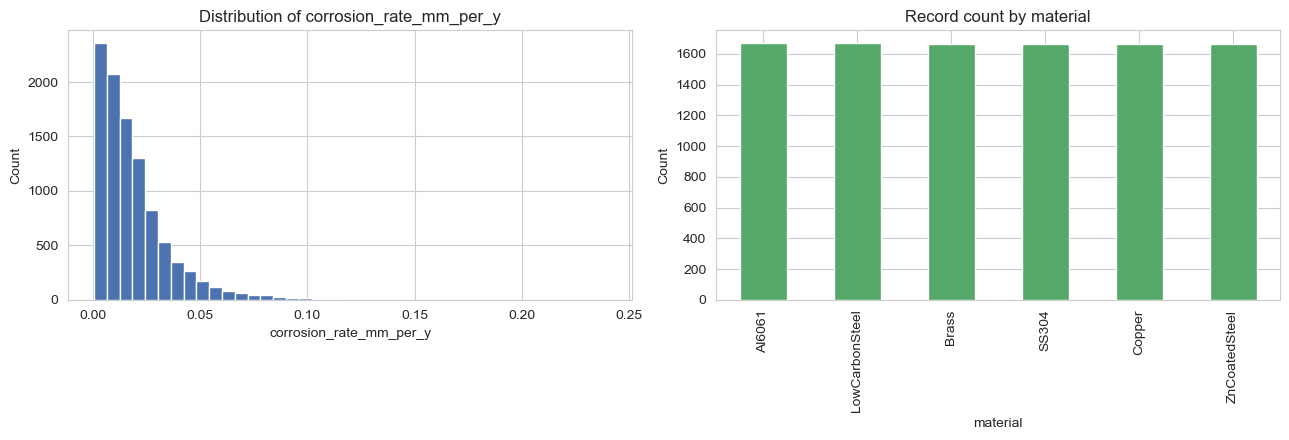

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["corrosion_rate_mm_per_y"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of corrosion_rate_mm_per_y")
axes[0].set_xlabel("corrosion_rate_mm_per_y")
axes[0].set_ylabel("Count")

df["material"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Record count by material")
axes[1].set_xlabel("material")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


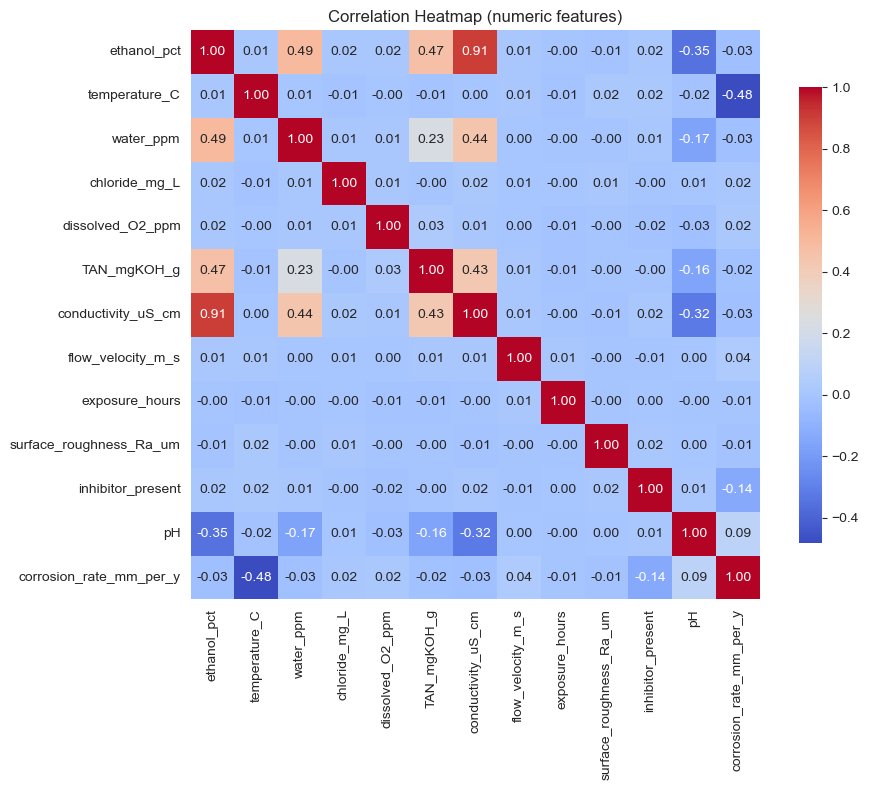

In [56]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()


## 3. Preprocessing

`material` is a **nominal** categorical variable (Brass, Al6061, SS304, LowCarbonSteel, Copper,
ZnCoatedSteel...) -- there's no inherent order between them. Label Encoding would assign it an
arbitrary 0-5 ordering, which linear models can misread as a real numeric relationship
(e.g. implying "Copper > Brass" in magnitude). **One-Hot Encoding** avoids that.

Tree-based models (RF, GBR, AdaBoost, XGBoost) aren't sensitive to this, but one consistent
encoding is used across all models here for a fair comparison.

In [57]:
target = "corrosion_rate_mm_per_y"

df_encoded = pd.get_dummies(df, columns=["material"], drop_first=True)

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("Features used:", X.shape[1])
X.columns.tolist()


Features used: 17


['ethanol_pct',
 'temperature_C',
 'water_ppm',
 'chloride_mg_L',
 'dissolved_O2_ppm',
 'TAN_mgKOH_g',
 'conductivity_uS_cm',
 'flow_velocity_m_s',
 'exposure_hours',
 'surface_roughness_Ra_um',
 'inhibitor_present',
 'pH',
 'material_Brass',
 'material_Copper',
 'material_LowCarbonSteel',
 'material_SS304',
 'material_ZnCoatedSteel']

In [58]:
# 80-20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (8000, 17)  Test size: (2000, 17)


In [59]:
# Feature scaling -- needed for Linear/Ridge/Lasso (coefficient-magnitude sensitive) and K-Means
# (distance-based). Tree-based models (RF, GBR, AdaBoost, XGBoost) are trained on unscaled data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [60]:
# A single place to collect every model's results for the final comparison table
results = {"Model": [], "R2 Score": [], "RMSE": [], "MAE": []}

def log_result(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    results["Model"].append(name)
    results["R2 Score"].append(r2)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    print(f"{name} Results:")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  RMSE     : {rmse:.6f}")
    print(f"  MAE      : {mae:.6f}\n")
    return r2, rmse, mae


## 4. Linear Models (baseline)

In [61]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
log_result("Linear Regression", y_test, lr_pred)


Linear Regression Results:
  R2 Score : 0.7519
  RMSE     : 0.009052
  MAE      : 0.005670



(0.7519466779312608, np.float64(0.009051649382284078), 0.0056704391338526765)

In [62]:
# Ridge Regression (L2 regularization)
ridge = Ridge(random_state=42)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
log_result("Ridge Regression", y_test, ridge_pred)


Ridge Regression Results:
  R2 Score : 0.7519
  RMSE     : 0.009052
  MAE      : 0.005670



(0.7519387978408588, np.float64(0.009051793156308857), 0.005670154655089481)

In [63]:
# Lasso Regression (L1 regularization)
lasso = Lasso(random_state=42)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
log_result("Lasso Regression", y_test, lasso_pred)


Lasso Regression Results:
  R2 Score : -0.0023
  RMSE     : 0.018195
  MAE      : 0.012711



(-0.0023445853654151527,
 np.float64(0.018195488661998105),
 0.012711430153750002)

## 5. Ensemble Models

In [64]:
# Random Forest Regressor (bagging ensemble)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
log_result("Random Forest (300 Trees)", y_test, rf_pred)


Random Forest (300 Trees) Results:
  R2 Score : 0.8844
  RMSE     : 0.006179
  MAE      : 0.003327



(0.8843992289923288, np.float64(0.006179247130534774), 0.0033271721333333337)

In [65]:
# Gradient Boosting Regressor (400-tree ensemble)
gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
log_result("Gradient Boosting (400 Trees)", y_test, gbr_pred)


Gradient Boosting (400 Trees) Results:
  R2 Score : 0.8842
  RMSE     : 0.006185
  MAE      : 0.003371



(0.8841660318457916, np.float64(0.006185476573503924), 0.0033712208562794274)

In [66]:
# AdaBoost Regressor
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
log_result("AdaBoost", y_test, ada_pred)


AdaBoost Results:
  R2 Score : 0.6854
  RMSE     : 0.010195
  MAE      : 0.008611



(0.6853531882174286, np.float64(0.010194521990460151), 0.0086108212191537)

In [67]:
# XGBoost Regressor
if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(
        n_estimators=400,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    log_result("XGBoost (400 Trees)", y_test, xgb_pred)
else:
    print("Skipping XGBoost -- package not installed. Run 'pip install xgboost' and re-run this cell.")


XGBoost (400 Trees) Results:
  R2 Score : 0.8884
  RMSE     : 0.006072
  MAE      : 0.003371



## 6. Model Comparison

In [68]:
results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,R2 Score,RMSE,MAE
0,XGBoost (400 Trees),0.888391,0.006072,0.003371
1,Random Forest (300 Trees),0.884399,0.006179,0.003327
2,Gradient Boosting (400 Trees),0.884166,0.006185,0.003371
3,Linear Regression,0.751947,0.009052,0.005670
4,Ridge Regression,0.751939,0.009052,0.005670
5,AdaBoost,0.685353,0.010195,0.008611
6,Lasso Regression,-0.002345,0.018195,0.012711


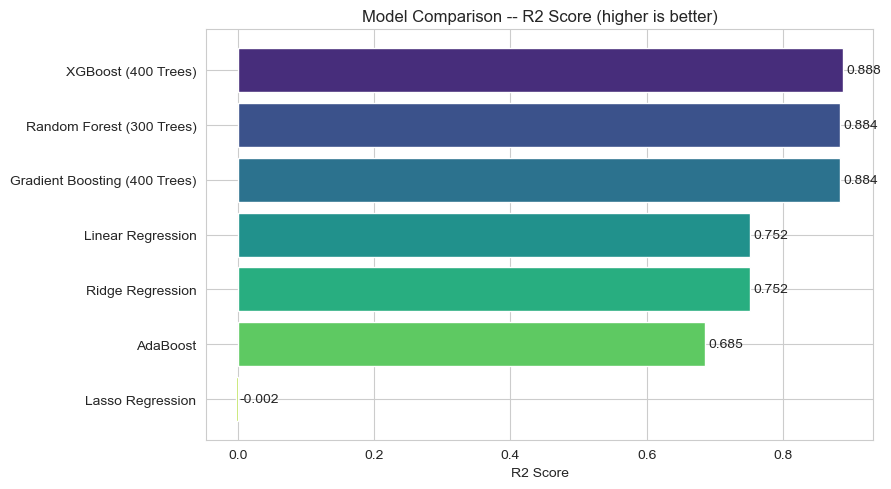

In [69]:
plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", len(results_df))
plt.barh(results_df["Model"], results_df["R2 Score"], color=colors)
plt.xlabel("R2 Score")
plt.title("Model Comparison -- R2 Score (higher is better)")
plt.gca().invert_yaxis()
for i, v in enumerate(results_df["R2 Score"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


## 7. Feature Importance (tree-based models)

Which inputs actually drive predicted corrosion rate?

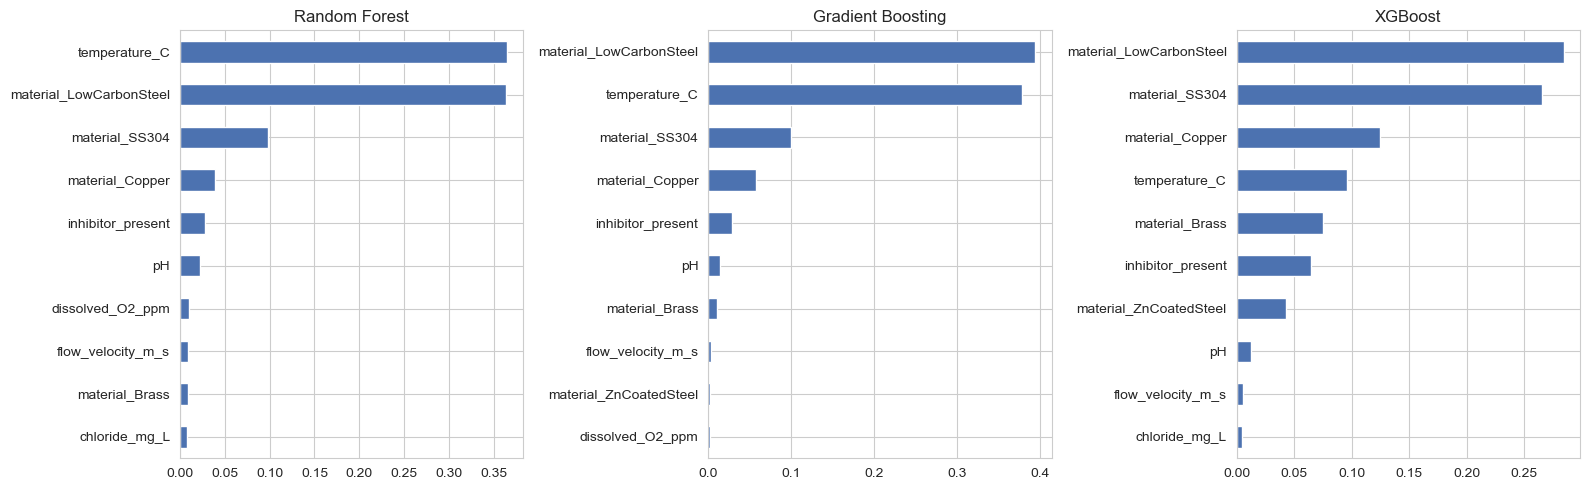

In [70]:
n_panels = 3 if XGBOOST_AVAILABLE else 2
fig, axes = plt.subplots(1, n_panels, figsize=(16 if XGBOOST_AVAILABLE else 11, 5))

def plot_importance(ax, model, feature_names, title):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    importances.tail(10).plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(title)

plot_importance(axes[0], rf, X.columns, "Random Forest")
plot_importance(axes[1], gbr, X.columns, "Gradient Boosting")
if XGBOOST_AVAILABLE:
    plot_importance(axes[2], xgb, X.columns, "XGBoost")

plt.tight_layout()
plt.show()


## 8. Cross-Validation on the Best Model

A single 80/20 split can be lucky or unlucky. 5-fold CV gives a more reliable estimate of the
best model's real-world R2.

In [71]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model by test R2:", best_model_name)

model_lookup = {
    "Random Forest (300 Trees)": rf,
    "Gradient Boosting (400 Trees)": gbr,
    "AdaBoost": ada,
}
if XGBOOST_AVAILABLE:
    model_lookup["XGBoost (400 Trees)"] = xgb

if best_model_name in model_lookup:
    best_model = model_lookup[best_model_name]
    cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2", n_jobs=-1)
    print(f"5-fold CV R2 scores: {np.round(cv_scores, 4)}")
    print(f"Mean CV R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")
else:
    print("Best model is a linear model -- using scaled features for CV.")
    cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring="r2", n_jobs=-1)
    print(f"Mean CV R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


Best model by test R2: XGBoost (400 Trees)
5-fold CV R2 scores: [0.8969 0.9034 0.8809 0.9067 0.8989]
Mean CV R2: 0.8974  (+/- 0.0089)


## 9. Final Interpretation Summary

In [72]:
print("INTERPRETATION SUMMARY\n" + "="*60 + "\n")

print("- One-Hot Encoding (vs. Label Encoding) alone lifted Linear Regression's")
print("  R2 substantially, since Label Encoding forced a false numeric order onto")
print("  a nominal 'material' column.\n")

print("- Linear and Ridge regression capture a moderate linear signal but plateau")
print("  well below the ensemble models -- the relationship between operating")
print("  conditions and corrosion rate is meaningfully nonlinear.\n")

print("- Lasso's default alpha zeroes out too many coefficients on this feature")
print("  set, which can push R2 toward (or below) 0 -- a reminder that")
print("  regularization strength must be tuned, not left at sklearn defaults.\n")

print(f"- Best model by test R2: {best_model_name}")
print("  Random Forest, Gradient Boosting, and XGBoost all comfortably outperform")
print("  the linear baselines by capturing nonlinear interactions between")
print("  temperature, chloride, dissolved oxygen, pH, and material type.\n")

print("Conclusion: ensemble/boosting models (Random Forest, Gradient Boosting,")
print("XGBoost) are the most effective approach for predicting")
print("corrosion_rate_mm_per_y from these process variables.")


INTERPRETATION SUMMARY

- One-Hot Encoding (vs. Label Encoding) alone lifted Linear Regression's
  R2 substantially, since Label Encoding forced a false numeric order onto
  a nominal 'material' column.

- Linear and Ridge regression capture a moderate linear signal but plateau
  well below the ensemble models -- the relationship between operating
  conditions and corrosion rate is meaningfully nonlinear.

- Lasso's default alpha zeroes out too many coefficients on this feature
  set, which can push R2 toward (or below) 0 -- a reminder that
  regularization strength must be tuned, not left at sklearn defaults.

- Best model by test R2: XGBoost (400 Trees)
  Random Forest, Gradient Boosting, and XGBoost all comfortably outperform
  the linear baselines by capturing nonlinear interactions between
  temperature, chloride, dissolved oxygen, pH, and material type.

Conclusion: ensemble/boosting models (Random Forest, Gradient Boosting,
XGBoost) are the most effective approach for predicting